# Preprocessing

In [1]:
import pandas as pd
import numpy as np
import os
import json
import kagglehub
import warnings
import traceback
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from sklearn.model_selection import RepeatedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

import itertools
import random

# Load preprocessing classes
os.chdir('../')  # Change to project root directory
# Preprocessing and utility imports
from utils.preprocessing.CarDatabase import ProductionCarMatcher, create_optimized_database
from utils.preprocessing.Cardinal_Preprocessor import CardinalMapper



print("SIMPLE ML TEMPLATE - FAST CLEAN DATA")
print("=" * 45)


param_grid_svr = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}


# CONFIGURATION - Change these as needed
CONFIG = {

    'random_state': 42,
    'target_column': 'price',
    
    # Preprocessing options
    'outlier_removal': True,          # Remove outliers?
    'feature_scaling': True,          # Scale features?
    'encoding_method': 'onehot',        # 'mean', 'onehot'
    
    # Feature transformations
    'log_transform_mileage': True,    # Log transform mileage?
    'convert_year_to_age': True,      # Convert year to car age?
    'normalize_paint': True,          # Normalize paint quality to 0-1?
    'normalize_engine': True,         # Convert engine size units?
    
    # Data splitting
    'test_size': 0.2,                 # Proportion of data for testing
    'feature_selection_size': 0.16,   # Proportion of training data for feature selection
    
    # Model selection
    'n_splits': 5,                   # Number of reppetead K-Fold splits
    'n_repeats': 5,                  # Number of repeats for K-Fold
    
    # Toggle a short search for fast iteration (set to False for full grid)
    'SHORT_SEARCH': False,
    'MAX_COMBINATIONS': 3,                              # when SHORT_SEARCH=True, sample up to this many combinations
    'model_class': RandomForestRegressor,               # can be SVR, RandomForestRegressor, MLPRegressor
    'param_grid': param_grid_rf                        # can be param_grid_svr, param_grid_rf, etc.
}
if CONFIG['SHORT_SEARCH']:
    CONFIG['n_splits'] = 2
    CONFIG['n_repeats'] = 2
    print("WARNING: SHORT_SEARCH is enabled. Using a subset of data and parameter combinations for quick testing, not for final evaluation.")
print(f"Configuration: {CONFIG}")

SIMPLE ML TEMPLATE - FAST CLEAN DATA
Configuration: {'random_state': 42, 'target_column': 'price', 'outlier_removal': True, 'feature_scaling': True, 'encoding_method': 'onehot', 'log_transform_mileage': True, 'convert_year_to_age': True, 'normalize_paint': True, 'normalize_engine': True, 'test_size': 0.2, 'feature_selection_size': 0.16, 'n_splits': 5, 'n_repeats': 5, 'SHORT_SEARCH': False, 'MAX_COMBINATIONS': 3, 'model_class': <class 'sklearn.ensemble._forest.RandomForestRegressor'>, 'param_grid': {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]}}


In [2]:
# Load datasets and quick sanity checks
raw_train_data = pd.read_csv('D:\\Mestrado\\MLearn2_2part\\ML_group_45-main\\Data\\train.csv')
test_data = pd.read_csv('D:\\Mestrado\\MLearn2_2part\\ML_group_45-main\\Data\\test.csv')
if CONFIG['SHORT_SEARCH']:
    raw_train_data = raw_train_data.sample(n=500, random_state=CONFIG['random_state']).reset_index(drop=True)
    test_data = test_data.sample(n=200, random_state=CONFIG['random_state']).reset_index(drop=True)

print(f"Loaded: train -> {raw_train_data.shape}, test -> {test_data.shape}")

print('\n--- Train dtypes ---')
print(raw_train_data.dtypes)

print('\n--- Train head (5 rows) ---')
display(raw_train_data.head(5))

print('\n--- Top 10 missing counts (train) ---')
print(raw_train_data.isnull().sum().sort_values(ascending=False).head(10))

missing_pct = (raw_train_data.isnull().mean() * 100).sort_values(ascending=False).head(10)
print('\n--- Top 10 missing percent (train) ---')
print(missing_pct.round(2))

# Keep canonical variable names used later in the notebook
train_data = raw_train_data.copy()


Loaded: train -> (75973, 14), test -> (32567, 13)

--- Train dtypes ---
carID               int64
Brand              object
model              object
year              float64
price               int64
transmission       object
mileage           float64
fuelType           object
tax               float64
mpg               float64
engineSize        float64
paintQuality%     float64
previousOwners    float64
hasDamage         float64
dtype: object

--- Train head (5 rows) ---


,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0



--- Top 10 missing counts (train) ---
mpg               7926
tax               7904
previousOwners    1550
hasDamage         1548
paintQuality%     1524
transmission      1522
Brand             1521
model             1517
engineSize        1516
fuelType          1511
dtype: int64

--- Top 10 missing percent (train) ---
mpg               10.43
tax               10.40
previousOwners     2.04
hasDamage          2.04
paintQuality%      2.01
transmission       2.00
Brand              2.00
model              2.00
engineSize         2.00
fuelType           1.99
dtype: float64


In [3]:
raw_train_data = pd.read_csv('D:\\Mestrado\\MLearn2_2part\\ML_group_45-main\\Data\\train.csv')
test_data = pd.read_csv('D:\\Mestrado\\MLearn2_2part\\ML_group_45-main\\Data\\test.csv')
path = kagglehub.dataset_download("bourzamraid/global-car-make-and-model-list")
with open(os.path.join(path, 'vehicle models.json'), 'r') as f:
    kaggle_data = json.load(f)
        
# Create matcher and clean brands
optimized_db = create_optimized_database(kaggle_data, max_model_words=3)
matcher = ProductionCarMatcher(optimized_db)
        
_, train_data_results  =  matcher.clean_dataframe(raw_train_data,
                                        'Brand',
                                        'model')
_, test_data_results  =  matcher.clean_dataframe(test_data,
                                        'Brand',
                                        'model')
# concat the cleaned data with the target column
train_data = pd.concat([raw_train_data.loc[train_data_results.index], train_data_results[['clean_make', 'clean_model']]], axis=1)
test_data = pd.concat([test_data.loc[test_data_results.index], test_data_results[['clean_make', 'clean_model']]], axis=1)
# dorp Brand and model columns
train_data = train_data.drop(columns=['Brand', 'model'])
test_data = test_data.drop(columns=['Brand', 'model'])

fueltype_dict = {
    'Petrol': (['petrol', 'petro', 'etrol', 'etro', 'petr', 'ptrol' ],
               [ 'diesel', 'hybrid', 'electric',  'other' ]),
    'Diesel': (['diesel', 'diese', 'iesel', 'iese', 'dise' ],
               [ 'petrol', 'hybrid', 'electric',  'other' ]),
    'Hybrid': (['hybrid', 'hybri', 'ybrid', 'ybri', 'hyb' ],
               [ 'petrol', 'diesel', 'electric',  'other' ]),
    'Electric': (['electric', 'elect', 'elec' ],
               [ 'petrol', 'diesel', 'hybrid',  'other' ]),
    'Other': (['other', 'othe', 'oth' ],
               [ 'petrol', 'diesel', 'hybrid',  'electric' ]) }

transmission_dict = {
    'Manual': ([ 'man', 'manual', 'm', 'stick', 'standard', 'mt' ],
               [ 'auto', 'semi', 'automatic', 'tiptronic', 'emi','mi','other' ]),
    'Semi-Auto': (['semi', 'semi-auto', 'tiptronic', 'emi','mi' ],
                    [ 'manual', 'stick', 'full manual', 'Other' ]),
    'Automatic': (['auto', 'automatic', 'a', 'at' ],
                  [ 'semi', 'manual', 'stick', 'tiptronic', 'emi','mi', 'other' ]) }


fuel_mapper = CardinalMapper(fueltype_dict)
transmission_mapper = CardinalMapper(transmission_dict)

print("Mapping fuelType and transmission columns...")
train_data['fuelType'] = fuel_mapper.fit_transform(train_data['fuelType'])
train_data['transmission'] = transmission_mapper.fit_transform(train_data['transmission'])
print(f"fuelType value counts:\n{train_data['fuelType'].value_counts()}")
test_data['fuelType'] = fuel_mapper.fit_transform(test_data['fuelType'])
test_data['transmission'] = transmission_mapper.fit_transform(test_data['transmission'])
print(f"transmission value counts:\n{train_data['transmission'].value_counts()}")


Analyzing word frequencies...
Created optimized database with 146 makes
Cleaning 75973 records...


Processing records: 100%|██████████| 75973/75973 [02:54<00:00, 434.52it/s]


Cleaning 32567 records...


Processing records: 100%|██████████| 32567/32567 [01:15<00:00, 432.08it/s]


Mapping fuelType and transmission columns...
fuelType value counts:
fuelType
Petrol      41181
Diesel      30885
Hybrid       2225
Other        1678
Electric        4
Name: count, dtype: int64
transmission value counts:
transmission
Manual       41627
Semi-Auto    16872
Automatic    15211
Other         2263
Name: count, dtype: int64


In [4]:
# Define transformations that can be applied to features
def log_transform(x:pd.Series)->pd.Series:
    return np.log1p(np.abs(x)+1)

def year_to_age(year_series:pd.Series)->pd.Series:
    return 2025 - np.abs(np.floor(year_series))

def normalize_paint(paint_series:pd.Series)->pd.Series:
    return np.clip(paint_series, 0, 100) / 100

def normalize_engine(engine_series:pd.Series)->pd.Series:
    result = engine_series.copy()
    small_engines = engine_series <= 10
    result[small_engines] = engine_series[small_engines] * 1000
    return result

In [5]:
from utils.preprocessing.Preprocessor_divided import DataPreprocessor

In [6]:
# Configure features
feature_configs = {
    'mileage': {
        'missing_strategy': 'median',
        'outlier_method': 'iqr' if CONFIG['outlier_removal'] else None,
        'transform_func': log_transform if CONFIG['log_transform_mileage'] else None,
        'scaling_method': 'standard' if CONFIG['feature_scaling'] else None
    },
    'year': {
        'missing_strategy': 'mean',
        'transform_func': year_to_age if CONFIG['convert_year_to_age'] else None,
        'scaling_method': 'minmax' if CONFIG['feature_scaling'] else None
    },
    'engineSize': {
        'missing_strategy': 'median',
        'transform_func': normalize_engine if CONFIG['normalize_engine'] else None,
        'scaling_method': 'robust' if CONFIG['feature_scaling'] else None
    },
    'tax': {
        'transform_func': lambda x: np.abs(x),
        'missing_strategy': 'median',
        'scaling_method': 'standard' if CONFIG['feature_scaling'] else None
    },
    'mpg': {
        'transform_func': lambda x: np.abs(x),
        'missing_strategy': 'median',
        'outlier_method': 'iqr' if CONFIG['outlier_removal'] else None,
        'scaling_method': 'standard' if CONFIG['feature_scaling'] else None
    },
    'paintQuality%': {
        'missing_strategy': 'median',
        'transform_func': normalize_paint if CONFIG['normalize_paint'] else None,
        'scaling_method': 'minmax' if CONFIG['feature_scaling'] else None
    },
    'previousOwners': {
        'missing_strategy': 'median',
        'transform_func': lambda x: np.log1p(np.abs(np.floor(x))),
        'scaling_method': 'standard' if CONFIG['feature_scaling'] else None
    },
    'hasDamage': {
        'missing_strategy': 1,
        'scaling_method': None
    },
    'clean_make': {
        'missing_strategy': 'mode',
        'encoding_method': 'mean'  # use mean encoding for make in any case, regardless of CONFIG because of high cardinality
    },
    'clean_model': {
        'missing_strategy': 'mode',
        'encoding_method': 'mean', # use mean encoding for models in any case, regardless of CONFIG because of high cardinality
    },
    'transmission': {
        'missing_strategy': 'mode',
        'encoding_method': CONFIG['encoding_method'],

    },
    'fuelType': {
        'missing_strategy': 'mode',
        'encoding_method': CONFIG['encoding_method'],
    }
}

In [7]:
data_temp = train_data.sample(frac=CONFIG['test_size'], random_state=CONFIG['random_state'])
data_val = train_data.drop(data_temp.index)
data_model_sel = data_temp.sample(frac=CONFIG['feature_selection_size'] , random_state=CONFIG['random_state'])
data_train = data_temp.drop(data_model_sel.index)

print(f"\n DATA SPLIT COMPLETE!")
print(f"   data_train: {data_train.shape}")
print(f"   data_model_sel: {data_model_sel.shape}")
print(f"   data_val: {data_val.shape}")

# fit_transform training data and transform feature selection and validation data
preprocessor = DataPreprocessor(target_column=CONFIG['target_column'])


for feature, feature_config in feature_configs.items():
    if feature in data_train.columns:
        preprocessor.add_feature_pipeline(feature, **feature_config)  
        
# we are already transformun the partitions becuse during k-fold CV we are going to fit_transform again and we don't want to lose the transformations for the final model validation
X_train, y_train = preprocessor.fit_transform(data_train)
X_feature_sel, y_model_sel = preprocessor.transform(data_model_sel)
X_val, y_val = preprocessor.transform(data_val)
X_test, y_test = preprocessor.transform(train_data)
test_data_processed, _ = preprocessor.transform(test_data)
del data_temp  # free memory
print("\n Preprocessing complete.")
print(f"   X_train: {X_train.shape}")
print(f"   X_feature_sel: {X_feature_sel.shape}")
print(f"   X_val: {X_val.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   test_data_processed: {test_data_processed.shape}")



 DATA SPLIT COMPLETE!
   data_train: (12764, 14)
   data_model_sel: (2431, 14)
   data_val: (60778, 14)

 Preprocessing complete.
   X_train: (12764, 18)
   X_feature_sel: (2431, 18)
   X_val: (60778, 18)
   X_test: (75973, 18)
   test_data_processed: (32567, 18)


In [8]:
choosen_features = X_train.drop(columns=['paintQuality%', 'previousOwners', 'hasDamage', 'transmission_Other', 'fuelType_Hybrid', 'fuelType_Other'])
choosen_features_feature_sel = X_feature_sel.drop(columns=['paintQuality%', 'previousOwners', 'hasDamage', 'transmission_Other', 'fuelType_Hybrid', 'fuelType_Other'])
choosen_features_val = X_val.drop(columns=['paintQuality%', 'previousOwners', 'hasDamage', 'transmission_Other', 'fuelType_Hybrid', 'fuelType_Other'])
choosen_features_test = X_test.drop(columns=['paintQuality%', 'previousOwners', 'hasDamage', 'transmission_Other', 'fuelType_Hybrid', 'fuelType_Other'])
choosen_features_test_data = test_data_processed.drop(columns=['paintQuality%', 'previousOwners', 'hasDamage', 'transmission_Other', 'fuelType_Hybrid', 'fuelType_Other'])

# Gradient Model

In [9]:
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
gb_basic = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=1.0,
    max_features='sqrt',
    random_state=42,
    verbose=0
)

print("\nTraining Basic Gradient Boosting Model...")
gb_basic.fit(choosen_features, y_train)
print("✓ Basic Gradient Boosting trained!")

# Make predictions
y_pred_gb_basic = gb_basic.predict(choosen_features_val)

# Evaluate basic model
residuals_gb_basic = y_val - y_pred_gb_basic
r2_gb_basic = r2_score(y_val, y_pred_gb_basic)
rmse_gb_basic = np.sqrt(mean_squared_error(y_val, y_pred_gb_basic))
mae_gb_basic = mean_absolute_error(y_val, y_pred_gb_basic)
mape_gb_basic = np.mean(np.abs(residuals_gb_basic / y_val)) * 100

print("\n BASIC GRADIENT BOOSTING PERFORMANCE:")
print("="*40)
print(f"   R² Score:            {r2_gb_basic:.4f}")
print(f"   RMSE:                {rmse_gb_basic:.2f}")
print(f"   MAE:                 {mae_gb_basic:.2f}")
print(f"   MAPE:                {mape_gb_basic:.2f}%")
print(f"   Std Dev Ratio:       {y_pred_gb_basic.std() / y_val.std():.4f}")


Training Basic Gradient Boosting Model...
✓ Basic Gradient Boosting trained!

📊 BASIC GRADIENT BOOSTING PERFORMANCE:
   R² Score:            0.8942
   RMSE:                3182.72
   MAE:                 1917.25
   MAPE:                12.29%
   Std Dev Ratio:       0.9239


In [11]:
print("\n" + "="*60)
print("HYPERPARAMETER TUNING (Randomized Search)")
print("="*60)

# Define parameter grid for Gradient Boosting
param_dist_gb = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

# Create base model
gb = GradientBoostingRegressor(random_state=42, verbose=0)

print("Starting Randomized Search for Gradient Boosting...")
print(f"  Sample size: {min(2000, len(choosen_features))} (for speed)")

# Use subset for faster tuning
sample_size_gb = min(2000, len(choosen_features))
X_sample_gb = choosen_features.iloc[:sample_size_gb] if hasattr(choosen_features, 'iloc') else choosen_features[:sample_size_gb]
y_sample_gb = y_train[:sample_size_gb]

# Randomized search
random_search_gb = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist_gb,
    n_iter=20,           # Number of parameter combinations to try
    cv=3,                # 3-fold cross-validation
    scoring='r2',
    verbose=1,
    random_state=42,
    n_jobs=-1,
    return_train_score=False
)

import time
start_time = time.time()

random_search_gb.fit(X_sample_gb, y_sample_gb)

end_time = time.time()
print(f"\n✓ Gradient Boosting tuning complete in {(end_time - start_time)/60:.1f} minutes!")

print(f"Best R² Score: {random_search_gb.best_score_:.4f}")
print(f"Best Parameters: {random_search_gb.best_params_}")


HYPERPARAMETER TUNING (Randomized Search)
Starting Randomized Search for Gradient Boosting...
  Sample size: 2000 (for speed)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✓ Gradient Boosting tuning complete in 0.1 minutes!
Best R² Score: 0.8975
Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 3, 'learning_rate': 0.1}


In [ ]:
# Train with best parameters on full data
gb_tuned = GradientBoostingRegressor(**random_search_gb.best_params_, 
                                     random_state=42, 
                                     verbose=0)

print("Training tuned Gradient Boosting model on full data...")
gb_tuned.fit(choosen_features, y_train)
print("✓ Tuned Gradient Boosting model trained!")

# Evaluate tuned model
y_pred_gb_tuned = gb_tuned.predict(choosen_features_val)
residuals_gb_tuned = y_val - y_pred_gb_tuned
r2_gb_tuned = r2_score(y_val, y_pred_gb_tuned)
rmse_gb_tuned = np.sqrt(mean_squared_error(y_val, y_pred_gb_tuned))
mae_gb_tuned = mean_absolute_error(y_val, y_pred_gb_tuned)

print(f"\n TUNED GRADIENT BOOSTING PERFORMANCE:")
print("="*40)
print(f"   R² Score:            {r2_gb_tuned:.4f}")
print(f"   RMSE:                {rmse_gb_tuned:.2f}")
print(f"   MAE:                 {mae_gb_tuned:.2f}")
print(f"   Improvement in R²:   {r2_gb_tuned - r2_gb_basic:.4f}")
print(f"   Improvement in RMSE: {rmse_gb_basic - rmse_gb_tuned:.2f}")

Training tuned Gradient Boosting model on full data...
✓ Tuned Gradient Boosting model trained!

📊 TUNED GRADIENT BOOSTING PERFORMANCE:
   R² Score:            0.9030
   RMSE:                3048.06
   MAE:                 1826.03
   Improvement in R²:   0.0088
   Improvement in RMSE: 134.66



Top 10 Most Important Features (Gradient Boosting):
               feature  importance
           clean_model    0.237063
            engineSize    0.195698
                  year    0.185068
               mileage    0.118960
   transmission_Manual    0.087828
            clean_make    0.074665
                   mpg    0.062049
                   tax    0.017919
transmission_Semi-Auto    0.009946
       fuelType_Petrol    0.005803


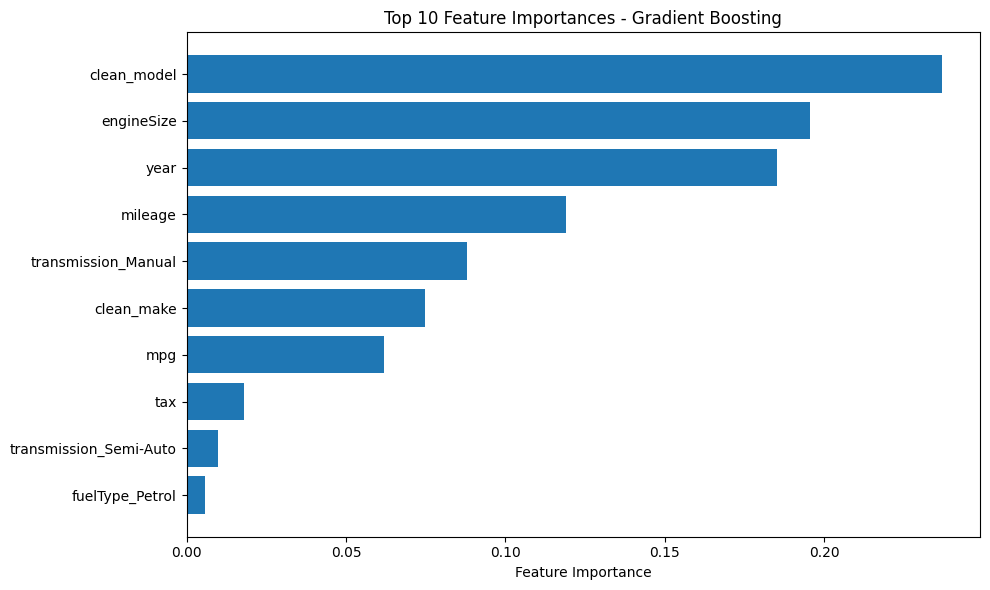

In [13]:
# Get feature importances
importances_gb = gb_tuned.feature_importances_
feature_names = choosen_features.columns if hasattr(choosen_features, 'columns') else [f'Feature_{i}' for i in range(choosen_features.shape[1])]

# Create DataFrame
importance_df_gb = pd.DataFrame({
    'feature': feature_names,
    'importance': importances_gb
}).sort_values('importance', ascending=False)

print(f"\nTop 10 Most Important Features (Gradient Boosting):")
print(importance_df_gb.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
top_features_gb = importance_df_gb.head(10)
plt.barh(range(len(top_features_gb)), top_features_gb['importance'])
plt.yticks(range(len(top_features_gb)), top_features_gb['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 10 Feature Importances - Gradient Boosting')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



Analyzing learning curve (performance vs number of trees)...


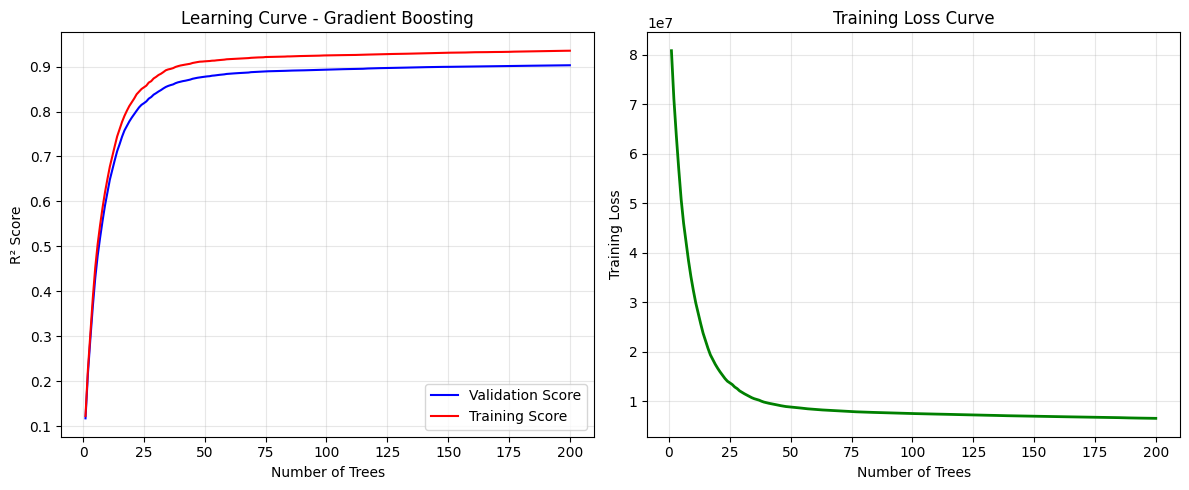

Best number of trees (validation): 200
Final number of trees: 200


In [14]:
print("\nAnalyzing learning curve (performance vs number of trees)...")

# Calculate test score for each stage
test_score = []
train_score = []

for i, y_pred in enumerate(gb_tuned.staged_predict(choosen_features_val)):
    test_score.append(r2_score(y_val, y_pred))

for i, y_pred in enumerate(gb_tuned.staged_predict(choosen_features.iloc[:2000])):
    train_score.append(r2_score(y_train[:2000], y_pred))

# Plot learning curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(test_score) + 1), test_score, 'b-', label='Validation Score')
plt.plot(range(1, len(train_score) + 1), train_score, 'r-', label='Training Score')
plt.xlabel('Number of Trees')
plt.ylabel('R² Score')
plt.title('Learning Curve - Gradient Boosting')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot loss curve
plt.subplot(1, 2, 2)
train_loss = gb_tuned.train_score_
plt.plot(range(1, len(train_loss) + 1), train_loss, 'g-', linewidth=2)
plt.xlabel('Number of Trees')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best number of trees (validation): {np.argmax(test_score) + 1}")
print(f"Final number of trees: {len(test_score)}")


In [ ]:
print("\n" + "="*60)
print("MAKING FINAL PREDICTIONS WITH GRADIENT BOOSTING")
print("="*60)

# Make predictions on test set
test_predictions_gb = gb_tuned.predict(choosen_features_test_data)

print(f"✓ Made Gradient Boosting predictions for {len(test_predictions_gb)} test samples")
print(f"\nGradient Boosting Prediction statistics:")
print(f"  Mean: {test_predictions_gb.mean():.2f}")
print(f"  Std:  {test_predictions_gb.std():.2f}")
print(f"  Min:  {test_predictions_gb.min():.2f}")
print(f"  Max:  {test_predictions_gb.max():.2f}")


MAKING FINAL PREDICTIONS WITH GRADIENT BOOSTING
✓ Made Gradient Boosting predictions for 32567 test samples

Gradient Boosting Prediction statistics:
  Mean: 16900.56
  Std:  9159.92
  Min:  -863.07
  Max:  97639.86


: 